<a href="https://colab.research.google.com/github/sandeep838116/Numpy/blob/main/NumPy_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparisons, Masks and Boolean Logic
- Boolean masks are used to examine and manipulate values within NumPy arrays.
- Masking comes when you want to extract, modify, count or otherwise manipulate values in an array based on some creterion.
- In NumPy, Boolean masking is often the most effective way to accomplish these types of tasks.

## Comparison Operators as ufuncs

- We know that +,-,*,/, and others on arrays lead to element-wise operations. NumPy also implements comparison operators such as <(less than) and >(greater than) as element-wise ufuncs. The result of these comparison operators is always an array with a Boolean data type.

In [1]:
import numpy as np
x = np.array([1,2,3,4,5])

In [2]:
x<3

array([ True,  True, False, False, False])

In [3]:
x>3

array([False, False, False,  True,  True])

In [4]:
x!=3

array([ True,  True, False,  True,  True])

In [5]:
x==3

array([False, False,  True, False, False])

In [6]:
# It is also possible to do an element-by-element comparison of two arrays, and to include compounded expressions.
(2*x)==(x**2)

array([False,  True, False, False, False])

In [7]:
# Just in case of arithematic ufuncs, these will work on arrays of any size and shape.
rng=np.random.RandomState(0)  #This initializes a random number generator. By passing a "seed" value (0), you lock the generator's starting point.
                              #This means that every time you run this script, it will generate the exact same sequence of "random" numbers,
                              # making your results reproducible.
x=rng.randint(10,size=(3,4))
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

In [8]:
x<6

array([[ True,  True,  True,  True],
       [False, False,  True,  True],
       [ True,  True, False, False]])

## Boolean Arrays

#### Counting entries

In [9]:
np.count_nonzero(x<6)   # To count the number of True entries in a boolean array, np.count_nonzero is useful.

8

In [10]:
print(np.sum(x<6))  # In this case, False is interpreted as 0, and True is interpreted as 1.

8


In [11]:
# The benefit of sum() is that like with other NumPy aggregation functions, this summation can be done along rows or colums as well.
np.sum(x<6,axis=1)  # This counts the numbers of values less than 6 in each row of the matrix.

array([4, 2, 2])

In [12]:
print(np.any(x>8)) # are there any values greater than 8

True


In [13]:
print(np.all(x<10)) # are all values less than 10

True


In [14]:
print(np.all(x<8, axis=1))  # np.all(),np.any() can be used along particular axes as well.

[ True False  True]


Note:- Python has built-in sum(), any(),all() functions. These have different syntax than the NumPy versions, and in particular will fail or produce unintended results when used on multidimensional arrays. Be sure that you are using np.sum(),np.any(),np.all().

### Boolean operators
- Python's bitwise logic operators, &,|,^,~, NumPy overloads these as ufuncs that work element-wise on (usually boolean) arrays.

In [15]:
rng=np.random.RandomState(0)
y=rng.randint(20,size=(3,4))
y

array([[12, 15,  0,  3],
       [ 3,  7,  9, 19],
       [18,  4,  6, 12]])

In [16]:
# (y > 3): Checks every number in the array to see if it is strictly greater than 3, creating a temporary grid of True and False values.
# (y < 5): Checks if every number is strictly less than 5.
# & (Bitwise AND): Combines the two conditions. It looks for numbers that are greater than 3 and less than 5. Since we are working with whole integers, the only number that satisfies this is 4.
# np.sum(...): In Python, True evaluates to 1 and False evaluates to 0. By taking the sum of this True/False grid, NumPy simply counts how many True values there are.

# The Output:
# When you run this code, it will print 1, because the number 4 only appears one time in this specific randomly generated array.

print(np.sum((y>3) & (y<5)))

1


- Note that the parenthesis here are important - because of operator precedence rules.
- Combining comparison operators and boolean operators on arrays can lead to a wide range of efficient logical operations.

## Boolean Arrays as Masks

A more powerful pattern is use Boolean arrays as masks, to select particular subsets of the data themselves.

In [17]:
y<5

array([[False, False,  True,  True],
       [ True, False, False, False],
       [False,  True, False, False]])

In [18]:
#Now to select these values from the array, we can simply index on this Boolean array; this is known as a masking operation.
y[y<5]

array([0, 3, 3, 4])

What is returned is a one dimensional array filled with all the values that meet this condition; in other words, all the values in positions at which the mask array is True.

# Fancy Indexing

Fancy indexing is conceptually simple: it means passing an array of indices to access multiple array elements at once.

In [19]:
rand=np.random.RandomState(42)
x=rand.randint(100,size=10)
print(x)

[51 92 14 71 60 20 82 86 74 74]


In [20]:
# Suppose you want to access three different elements. We can do it like this:
print([x[3],x[7],x[2]])

[np.int64(71), np.int64(86), np.int64(14)]


In [21]:
# Alternatively, you can pass a single list or array of indices to obtain the same result:
ind=[3,7,4]
x[ind]

array([71, 86, 60])

**Note :- With fancy indexing, the shape of the result reflects the shape of the index arrays rather than the shape of the array being indexed.**

In [22]:
ind =np.array([[3,7],
              [4,5]])
x[ind]

array([[71, 86],
       [60, 20]])

In [23]:
# Fancy indexing also works in multiple dimensions. Like with the standard indexing, the first index refers to the row, and the second to the column.
x=np.arange(12).reshape((3,4))
x

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [24]:
row=np.array([0,1,2])
column=np.array([2,1,3])
x[row,column]

array([ 2,  5, 11])

**Note:- The pairing of indices in fancy indexing follows all the broadcasting rules.**

In [25]:
x[row[:,np.newaxis],column]

# row[:,np.newaxis]: This takes your flat row array [0, 1, 2] and turns it into a vertical column vector (a 3x1 matrix).

# Broadcasting: Because you are passing a 3x1 vertical row array and a 1x3 horizontal column array into the index brackets [],
# NumPy "broadcasts" them together to form a 3x3 grid. It matches every row index with every column index.

array([[ 2,  1,  3],
       [ 6,  5,  7],
       [10,  9, 11]])

It is always important to remember with fancy indexing that the return value reflects the broadcasted shape of the indices, rather than the shape of the array being indexed.

## Combined Indexing

In [26]:
x

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [27]:
x[2,[2,0,1]]  # We can combine fancy and simple indexing.

array([10,  8,  9])

In [28]:
x[1:,[2,0,1]] # We can combine fancy indexing with slicing.

array([[ 6,  4,  5],
       [10,  8,  9]])

In [29]:
# We can combine fancy indexing with masking
mask=np.array([1,0,1,0],dtype=bool)   #This creates a 1D array of True/False values: [True, False, True, False]. Because this mask has exactly 4 items, it aligns perfectly with the 4 columns in your base array x.

                                      # It acts as an on/off switch for the columns:

                                        # Index 0 is True (Keep Column 0)

                                        # Index 1 is False (Drop Column 1)

                                        # Index 2 is True (Keep Column 2)

                                        # Index 3 is False (Drop Column 3)

                                      # Effectively, this mask tells NumPy to only look at columns 0 and 2.
x[row[:,np.newaxis],mask]   # Broadcasting with rows

array([[ 0,  2],
       [ 4,  6],
       [ 8, 10]])

## Selecting random points

- One common use of fancy indexing is the selection of subsets of rows from a matrix.
- for example, we might have an N by D matrix representing N points in D dimensions, such as the following points drawn from a two dimensional normal distribution:

In [30]:
mean =[0,0]
cov = [[1,2],[2,5]]
x = rand.multivariate_normal(mean,cov,100)
x.shape

(100, 2)

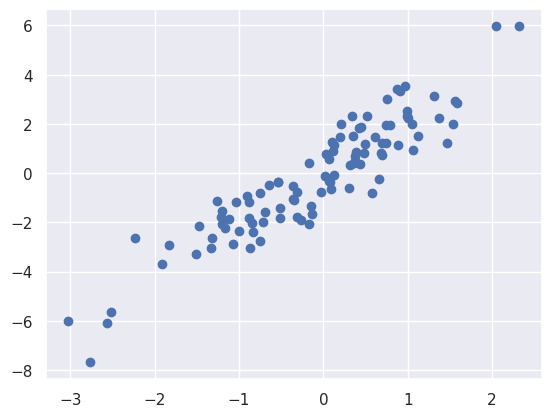

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set()   # for plot styling

plt.scatter(x[:,0],x[:,1])

In [32]:
# we will select 20 random points using fancy indexing with no repeats, and use indices to select a portion of the original array:
indices = np.random.choice(x.shape[0],20,replace=False)
indices

array([93, 57, 77, 90, 87, 73, 17, 27, 84,  7, 58, 22, 33, 91, 76, 12, 71,
       98, 59, 80])

In [33]:
selection = x[indices]
selection.shape

(20, 2)

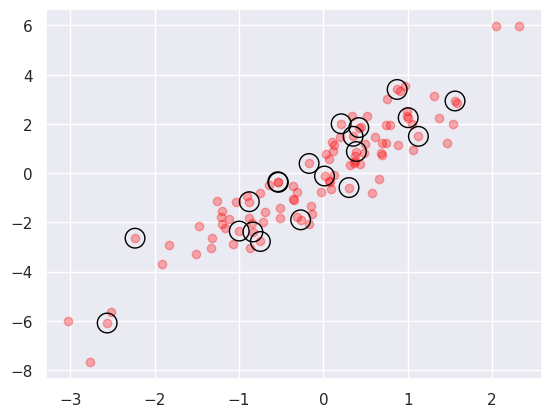

In [38]:
plt.scatter(x[:,0],x[:,1],alpha=0.3,c='red')
plt.scatter(selection[:,0],selection[:,1],facecolor='none',s=200,edgecolors='black')

This sort of stratergy is often is used to quickly partition datasets, as is often needed in train/test splitting for validation of stastical models and in sampling approaches to answering statistical questions.

## Modifying Values With Fancy Indexing
- Just as fancy indexing can be used to access part of an array, it can be also used to modify parts of array.

In [40]:
x=np.arange(10)
i=np.array([2,1,8,4])
x[i]=99
print(x)

[ 0 99 99  3 99  5  6  7 99  9]


In [41]:
x[i]-=10    # we can use any assignment-type operator for this
print(x)

[ 0 89 89  3 89  5  6  7 89  9]


In [42]:
x=np.zeros(10)
x[[0,0]]=[4,6]
print(x)

[6. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Where did the 4 go? The result of this operation is to first assign x[0]=4, followed by x[0]=6. The result, of course, is that x[0] contains the value 6.

In [43]:
i=[2,3,3,4,4,4]
x[i]+=1
x

array([6., 0., 1., 1., 1., 0., 0., 0., 0., 0.])

You might expect that `x[3]` would contain the value `2`, and `x[4]` would contain the value `3`, as this is how many times each index is repeated. Why is this not the case?

Conceptually, this is because `x[i] += 1` is meant as a shorthand for `x[i] = x[i] + 1`.

You might intuitively read this as *"go to index 3 and add 1, then go to index 3 again and add 1."* However, `x[i] + 1` is evaluated first, and *then* the result is assigned to the indices in `x`. With this in mind, **it is not the augmentation that happens multiple times, but the assignment**, which leads to the rather non-intuitive results.

Under the hood, NumPy executes this in two distinct steps:

1. **Evaluate:** It looks at all the current values at indices `[2, 3, 3, 4, 4, 4]`. Since they are all `0`, adding `1` makes them all `1`.
2. **Assign:** It takes those `1`s and assigns them back to the original indices `[2, 3, 3, 4, 4, 4]`.

For index `4`, it assigns the value `1` to it. Then it assigns `1` to it again. Then it assigns `1` to it a third time. **It does not accumulate the additions.**

So what if you want to the other behaviour where the operation is repeated? For this you can use the at() method of ufuncs.<br>The at() method does an in-place appliction of the given operator at the specified indices with the specified value.<br>Another method that is similar in spirit is the reduceat() method of ufuncs.

In [44]:
x=np.zeros(10)
np.add.at(x,i,1)
print(x)

[0. 0. 1. 2. 3. 0. 0. 0. 0. 0.]
